In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from google.colab import files

uploaded = files.upload()

Saving Superstore.csv to Superstore (1).csv


In [9]:
from google.colab import files

uploaded = files.upload()

Saving Superstore.csv to Superstore (2).csv


In [10]:
import os

print(os.listdir())

['.config', 'Superstore.csv', 'Superstore (1).csv', 'Superstore (2).csv', 'sample_data']


In [12]:
import pandas as pd

df = pd.read_csv("Superstore.csv", encoding="latin1")

In [13]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
df.columns.tolist()


['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [15]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [16]:
df.duplicated().sum()


np.int64(0)

In [17]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [21]:
df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [22]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [23]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

In [24]:
df[['Order Date', 'Year', 'Month', 'Month Name']].head()

,Order Date,Year,Month,Month Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


In [25]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2297200.8603000003


In [26]:
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 286397.0217


In [27]:
total_quantity = df['Quantity'].sum()
print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 37873


In [28]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


In [29]:
total_customers = df['Customer ID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


In [30]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


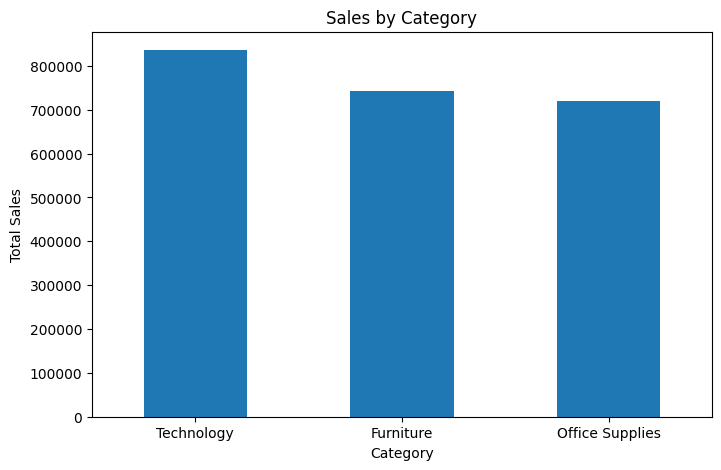

In [31]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

In [32]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


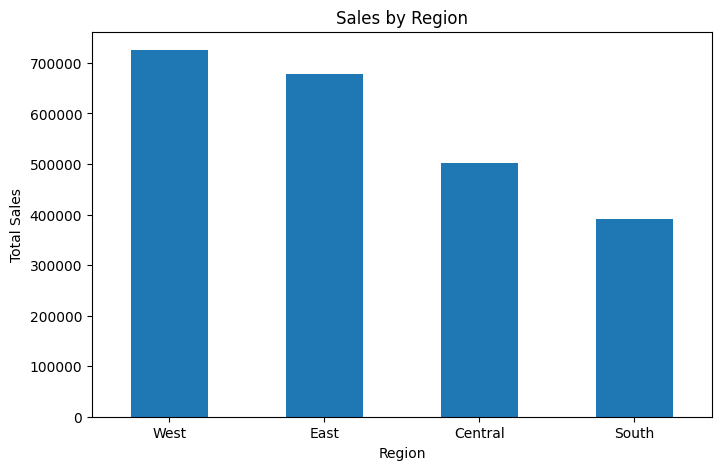

In [33]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

In [34]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print(subcategory_sales)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


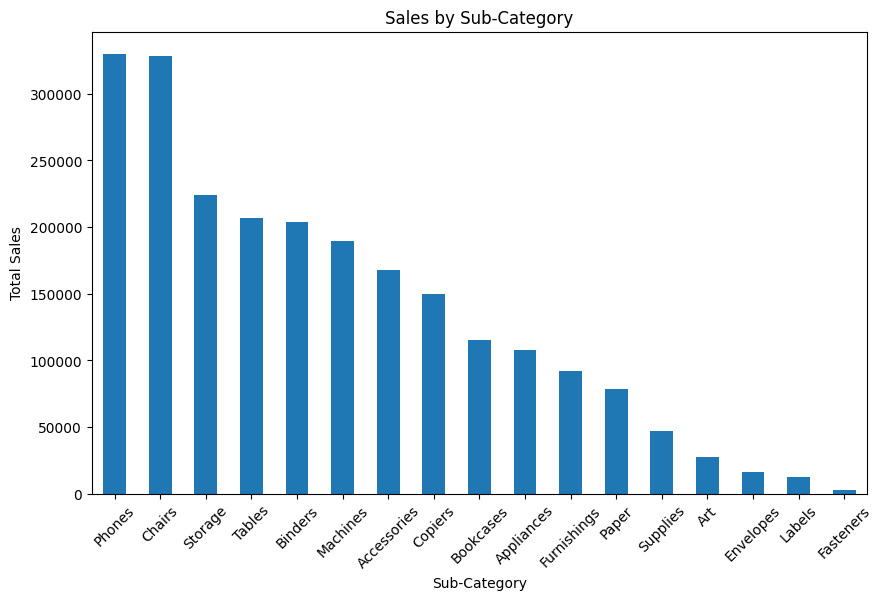

In [35]:
plt.figure(figsize=(10,6))

subcategory_sales.plot(kind='bar')

plt.title('Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

In [36]:
monthly_sales = df.groupby(
    ['Year', 'Month']
)['Sales'].sum()

print(monthly_sales)

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         

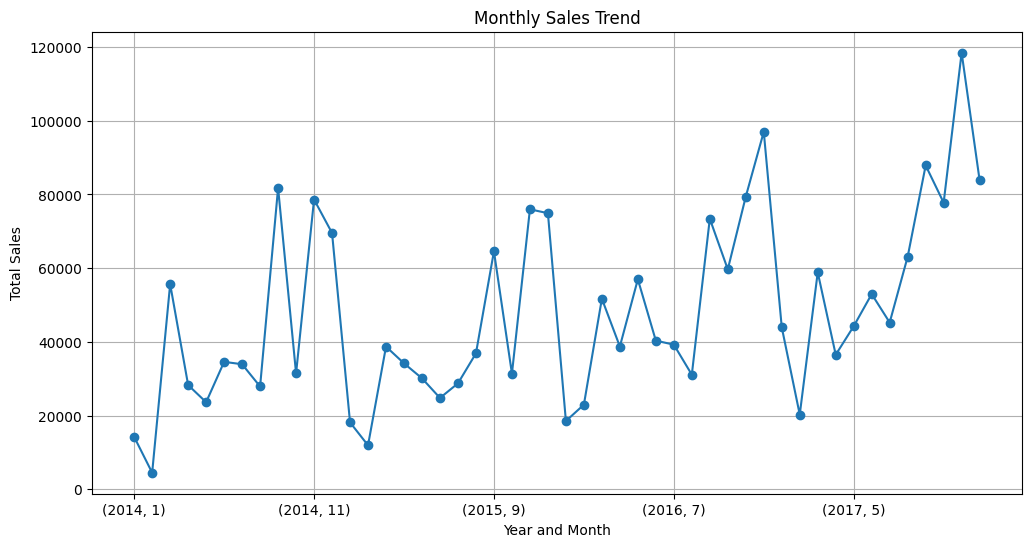

In [37]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Year and Month')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

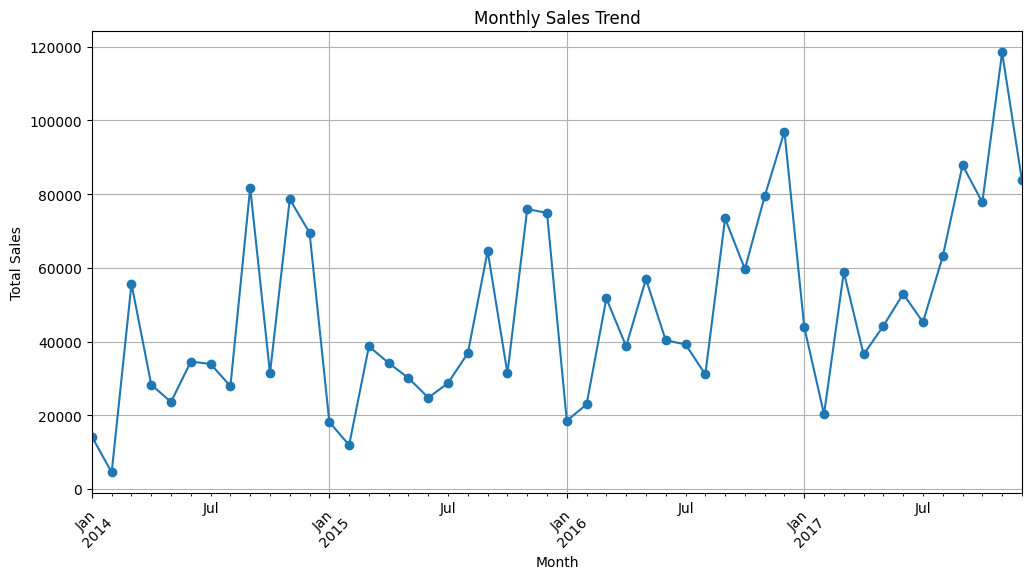

In [38]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

plt.figure(figsize=(12, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [39]:
top_products = df.groupby(
    'Product Name'
)['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


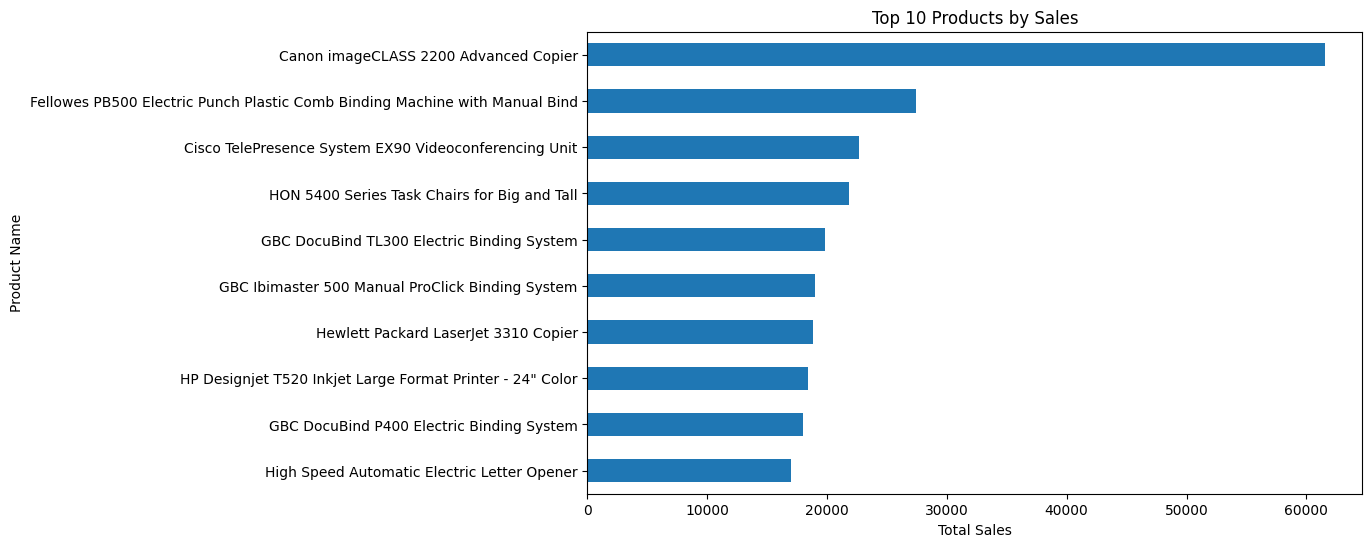

In [40]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')

plt.show()

In [41]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


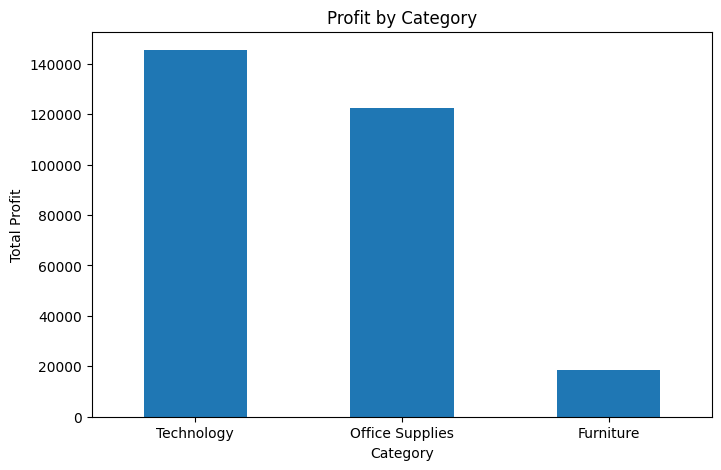

In [42]:
plt.figure(figsize=(8,5))

category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)

plt.show()

In [43]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


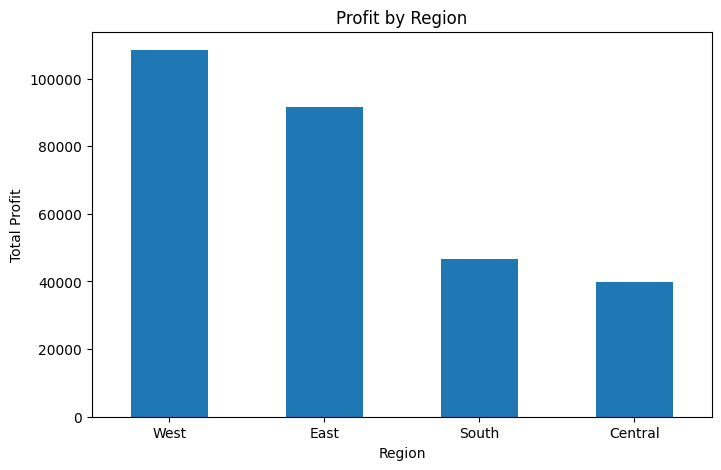

In [44]:
plt.figure(figsize=(8,5))

region_profit.plot(kind='bar')

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)

plt.show()

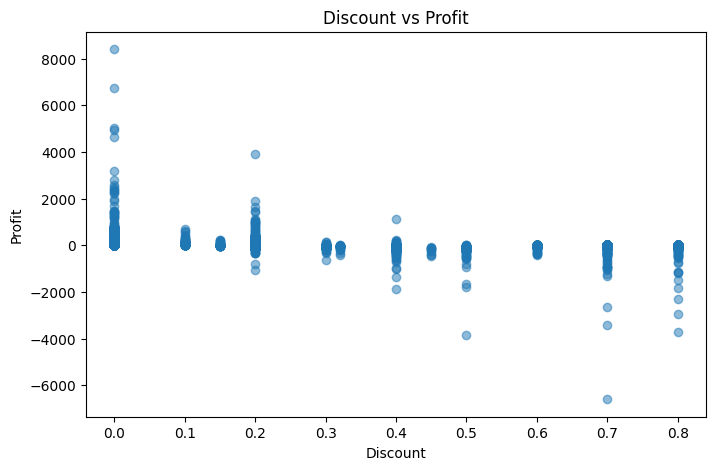

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(df['Discount'], df['Profit'], alpha=0.5)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

In [46]:
loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

print(loss_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


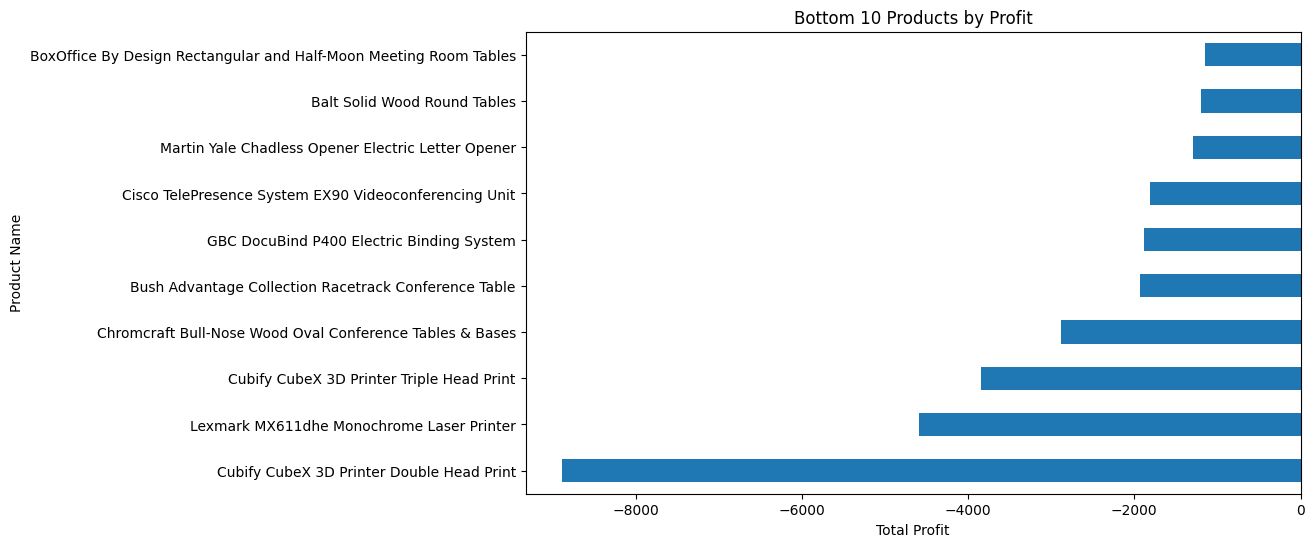

In [47]:
plt.figure(figsize=(10,6))

loss_products.sort_values().plot(kind='barh')

plt.title('Bottom 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')

plt.show()

In [48]:
print("========== SALES DASHBOARD ==========")
print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Total Customers  : {total_customers:,}")
print(f"Total Quantity   : {total_quantity:,}")

========== SALES DASHBOARD ==========
Total Sales      : $2,297,200.86
Total Profit     : $286,397.02
Total Orders     : 5,009
Total Customers  : 793
Total Quantity   : 37,873


In [49]:
profit_margin = (total_profit / total_sales) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 12.47%


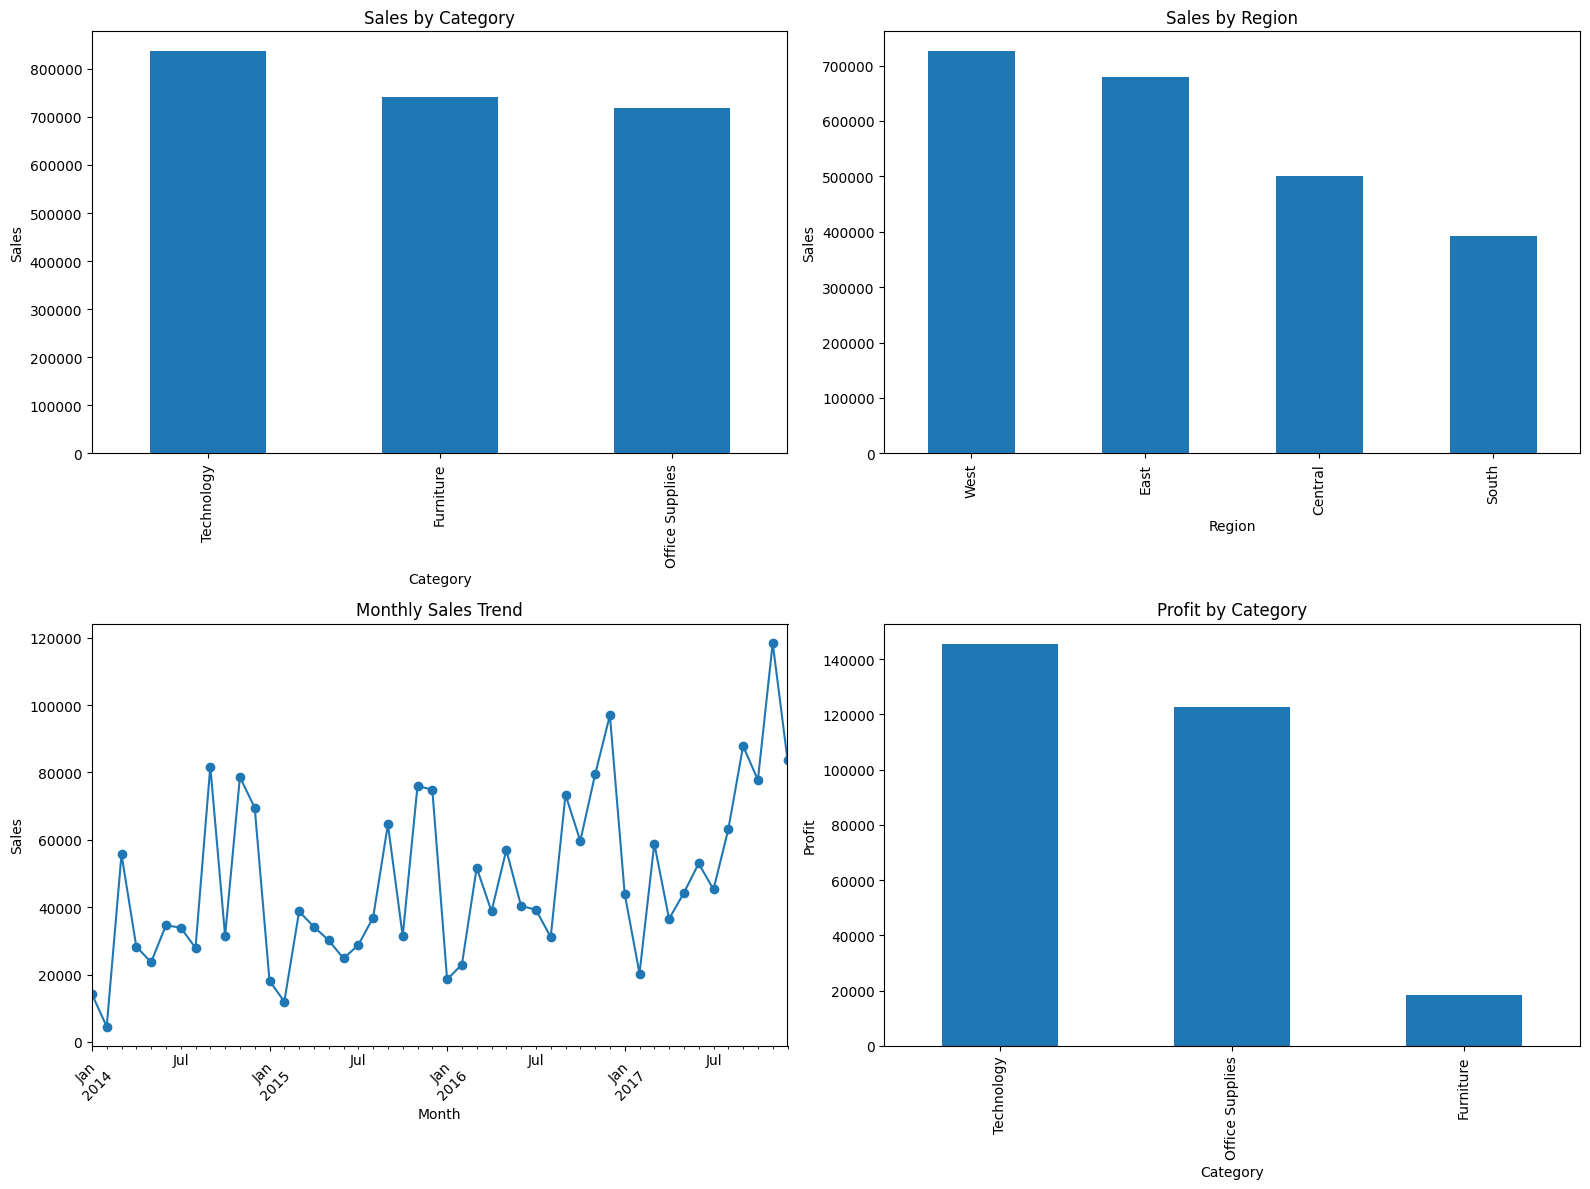

<Figure size 640x480 with 0 Axes>

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sales by Category
category_sales.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Sales')

# 2. Sales by Region
region_sales.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Sales by Region')
axes[0,1].set_xlabel('Region')
axes[0,1].set_ylabel('Sales')

# 3. Monthly Sales Trend
monthly_sales.plot(kind='line', marker='o', ax=axes[1,0])
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Sales')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Profit by Category
category_profit.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Profit by Category')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

plt.savefig("sales_analysis_dashboard.png", dpi=300, bbox_inches="tight")

In [51]:
plt.savefig("sales_analysis_dashboard.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [52]:
plt.savefig("sales_analysis_dashboard.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [54]:
plt.suptitle('Sales Data Analysis Dashboard', fontsize=18)
plt.tight_layout()

plt.savefig("sales_analysis_dashboard.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

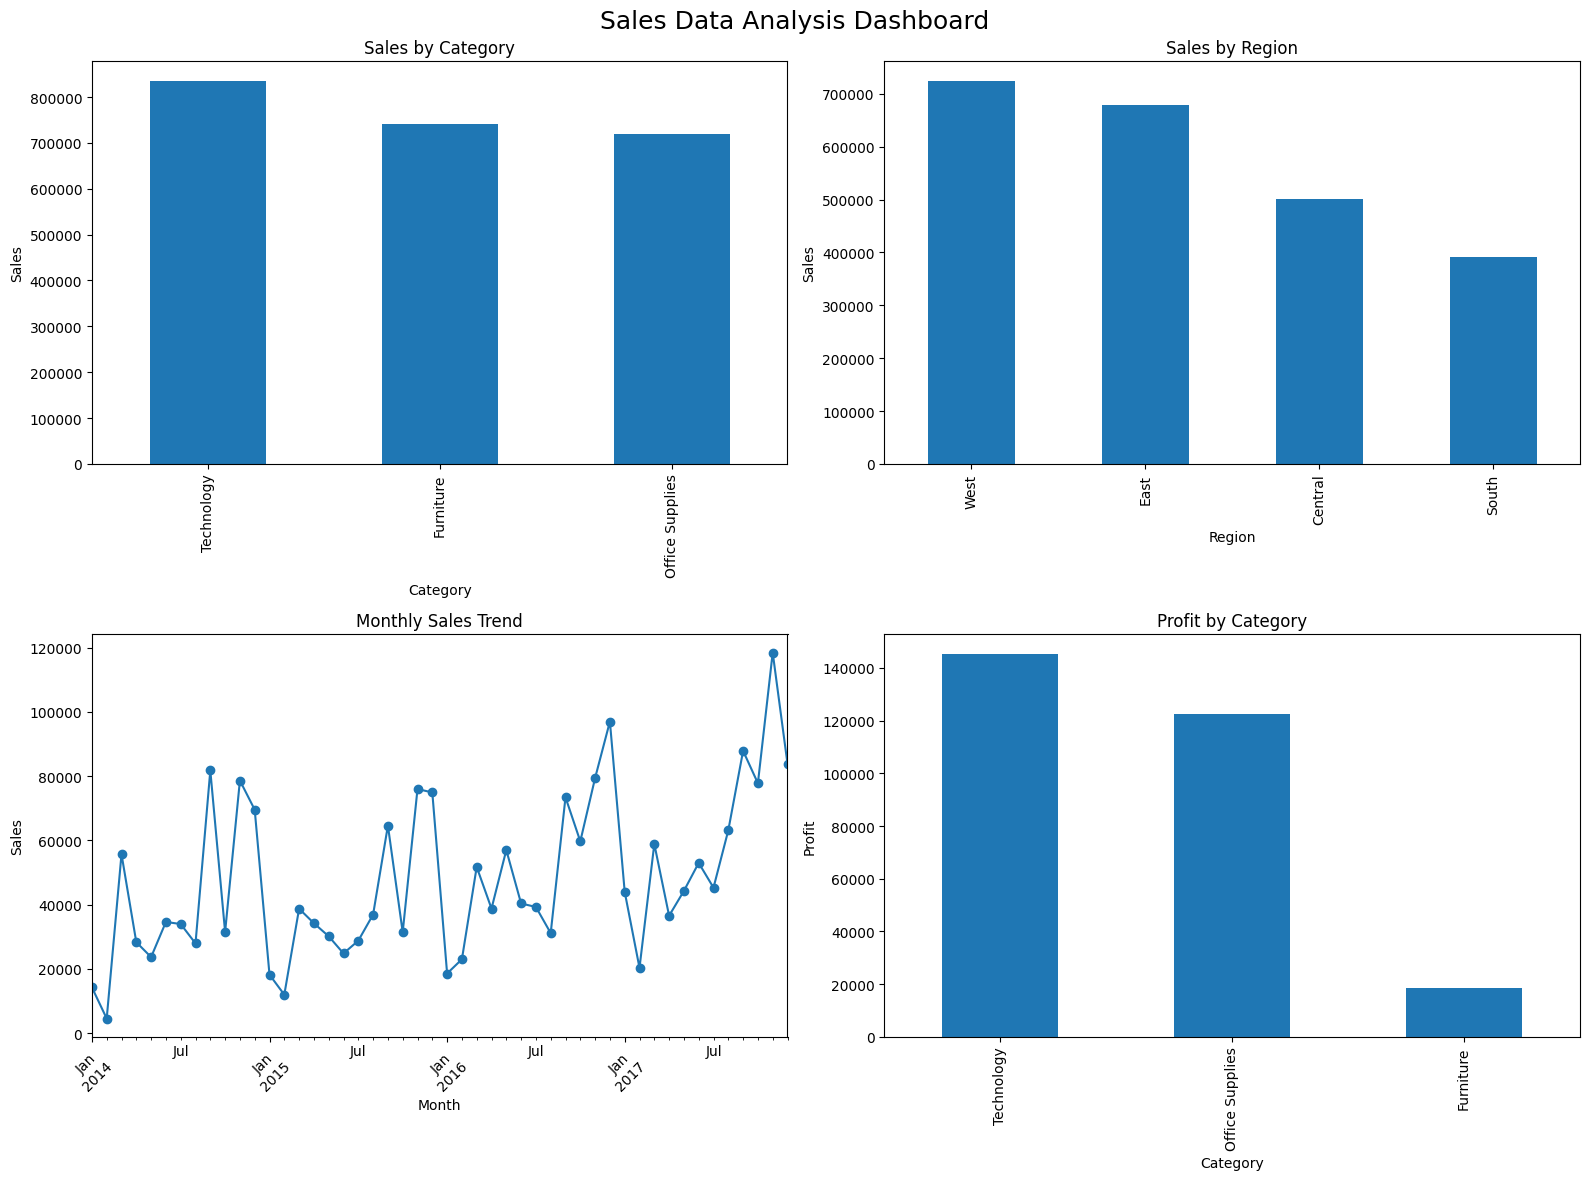

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sales by Category
category_sales.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Sales')

# Sales by Region
region_sales.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Sales by Region')
axes[0,1].set_xlabel('Region')
axes[0,1].set_ylabel('Sales')

# Monthly Sales Trend
monthly_sales.plot(kind='line', marker='o', ax=axes[1,0])
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Sales')
axes[1,0].tick_params(axis='x', rotation=45)

# Profit by Category
category_profit.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Profit by Category')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Profit')

plt.suptitle('Sales Data Analysis Dashboard', fontsize=18)
plt.tight_layout()

# Save dashboard
plt.savefig("sales_analysis_dashboard.png", dpi=300, bbox_inches="tight")

plt.show()

In [56]:
from google.colab import files

files.download("sales_analysis_dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
print("""
SALES DATA ANALYSIS DASHBOARD

Introduction:
This project analyzes sales data to understand sales performance,
profitability, customer activity, and regional trends.

Objective:
- Clean and prepare the sales dataset
- Perform exploratory data analysis
- Identify important sales and profit trends
- Create meaningful visualizations
- Generate business insights

Tools Used:
- Python
- Pandas
- Matplotlib
- Google Colab

Dataset:
Superstore Sales Dataset
""")


SALES DATA ANALYSIS DASHBOARD

Introduction:
This project analyzes sales data to understand sales performance,
profitability, customer activity, and regional trends.

Objective:
- Clean and prepare the sales dataset
- Perform exploratory data analysis
- Identify important sales and profit trends
- Create meaningful visualizations
- Generate business insights

Tools Used:
- Python
- Pandas
- Matplotlib
- Google Colab

Dataset:
Superstore Sales Dataset



In [58]:
print("========== KEY PERFORMANCE INDICATORS ==========")
print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Total Customers  : {total_customers:,}")
print(f"Total Quantity   : {total_quantity:,}")
print(f"Profit Margin    : {profit_margin:.2f}%")

========== KEY PERFORMANCE INDICATORS ==========
Total Sales      : $2,297,200.86
Total Profit     : $286,397.02
Total Orders     : 5,009
Total Customers  : 793
Total Quantity   : 37,873
Profit Margin    : 12.47%


In [59]:
print("""
========== BUSINESS INSIGHTS ==========

1. Technology is the highest-selling category, indicating strong demand
   for technology-related products.

2. The West region has the highest sales among all regions, making it
   an important market for the business.

3. Phones and Chairs are among the top-performing sub-categories
   based on sales.

4. Profitability varies across products and categories. Some products
   generate lower or negative profits and may require further review.

5. Discount levels can affect profitability, so discount strategies
   should be monitored carefully.

6. The overall business generated strong sales and positive profit,
   indicating good overall business performance.
""")


========== BUSINESS INSIGHTS ==========

1. Technology is the highest-selling category, indicating strong demand
   for technology-related products.

2. The West region has the highest sales among all regions, making it
   an important market for the business.

3. Phones and Chairs are among the top-performing sub-categories
   based on sales.

4. Profitability varies across products and categories. Some products
   generate lower or negative profits and may require further review.

5. Discount levels can affect profitability, so discount strategies
   should be monitored carefully.

6. The overall business generated strong sales and positive profit,
   indicating good overall business performance.



In [60]:
print("""
========== CONCLUSION ==========

The sales data analysis provided a clear understanding of the company's
sales and profit performance.

The analysis identified the best-performing categories, regions, and
sub-categories and highlighted areas that require attention for better
profitability.

The dashboard presents the key findings in an easy-to-understand visual
format and can help support data-driven business decisions.

Overall, this project demonstrates how Python and data visualization
can be used to analyze sales data and generate meaningful business
insights.
""")


========== CONCLUSION ==========

The sales data analysis provided a clear understanding of the company's
sales and profit performance.

The analysis identified the best-performing categories, regions, and
sub-categories and highlighted areas that require attention for better
profitability.

The dashboard presents the key findings in an easy-to-understand visual
format and can help support data-driven business decisions.

Overall, this project demonstrates how Python and data visualization
can be used to analyze sales data and generate meaningful business
insights.



In [61]:
import os

print(os.path.exists("sales_analysis_dashboard.png"))

True


In [63]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import inch

pdf_file = "Sales_Analysis_Report.pdf"

doc = SimpleDocTemplate(
    pdf_file,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleStyle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=20,
    spaceAfter=20
)

heading_style = ParagraphStyle(
    "HeadingStyle",
    parent=styles["Heading2"],
    fontSize=14,
    spaceBefore=12,
    spaceAfter=8
)

body_style = styles["BodyText"]

story = []

# Title
story.append(Paragraph("Sales Data Analysis Dashboard", title_style))
story.append(Paragraph("Skyrovix Internship - Task 1", body_style))
story.append(Spacer(1, 20))

# Introduction
story.append(Paragraph("1. Introduction", heading_style))
story.append(Paragraph(
    "This project analyzes the Superstore sales dataset to understand "
    "sales performance, profitability, customer activity, and regional trends.",
    body_style
))

# Objective
story.append(Paragraph("2. Objective", heading_style))
story.append(Paragraph(
    "• Clean and prepare the sales dataset<br/>"
    "• Perform exploratory data analysis<br/>"
    "• Identify important sales and profit trends<br/>"
    "• Create meaningful visualizations<br/>"
    "• Generate business insights",
    body_style
))

# Tools
story.append(Paragraph("3. Tools Used", heading_style))
story.append(Paragraph(
    "Python, Pandas, Matplotlib, and Google Colab.",
    body_style
))

# Dataset
story.append(Paragraph("4. Dataset", heading_style))
story.append(Paragraph(
    "The project uses the Superstore Sales Dataset containing information "
    "about orders, customers, products, sales, quantity, discounts, and profit.",
    body_style
))

# Cleaning
story.append(Paragraph("5. Data Cleaning", heading_style))
story.append(Paragraph(
    "The dataset was loaded using Pandas. Duplicate records were checked, "
    "date columns were converted into datetime format, and additional "
    "Year and Month fields were created for analysis.",
    body_style
))

# KPIs
story.append(Paragraph("6. Key Performance Indicators", heading_style))
story.append(Paragraph(
    f"Total Sales: ${total_sales:,.2f}<br/>"
    f"Total Profit: ${total_profit:,.2f}<br/>"
    f"Total Orders: {total_orders:,}<br/>"
    f"Total Customers: {total_customers:,}<br/>"
    f"Total Quantity Sold: {total_quantity:,}<br/>"
    f"Profit Margin: {profit_margin:.2f}%",
    body_style
))

# Analysis
story.append(Paragraph("7. Analysis and Visualizations", heading_style))
story.append(Paragraph(
    "The analysis covers sales by category, sales by region, monthly sales "
    "trends, and profit by category. Additional analysis was performed for "
    "sub-categories, top products, discount versus profit, and low-profit products.",
    body_style
))

# Dashboard
story.append(Paragraph("8. Sales Analysis Dashboard", heading_style))

dashboard_img = Image(
    "sales_analysis_dashboard.png",
    width=7.0 * inch,
    height=5.2 * inch
)

story.append(dashboard_img)
story.append(Spacer(1, 15))

# Insights
story.append(Paragraph("9. Business Insights", heading_style))
story.append(Paragraph(
    "• Technology is the highest-selling category.<br/>"
    "• West is the highest-selling region.<br/>"
    "• Phones and Chairs are among the top-performing sub-categories.<br/>"
    "• Profitability varies across products and categories.<br/>"
    "• Discount levels should be monitored carefully because they can affect profitability.",
    body_style
))

# Conclusion
story.append(Paragraph("10. Conclusion", heading_style))
story.append(Paragraph(
    "The analysis provided a clear understanding of sales and profit performance. "
    "The dashboard summarizes the major findings in an easy-to-understand format "
    "and can support data-driven business decisions.",
    body_style
))

doc.build(story)

print("PDF created successfully:", pdf_file)

ModuleNotFoundError: No module named 'reportlab'

In [65]:
!pip install reportlab

In [66]:
!pip install reportlab

In [67]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import inch

pdf_file = "Sales_Analysis_Report.pdf"

doc = SimpleDocTemplate(
    pdf_file,
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleStyle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=20,
    spaceAfter=20
)

heading_style = ParagraphStyle(
    "HeadingStyle",
    parent=styles["Heading2"],
    fontSize=14,
    spaceBefore=12,
    spaceAfter=8
)

body_style = styles["BodyText"]

story = []

story.append(Paragraph("Sales Data Analysis Dashboard", title_style))
story.append(Paragraph("Skyrovix Internship - Task 1", body_style))
story.append(Spacer(1, 20))

story.append(Paragraph("1. Introduction", heading_style))
story.append(Paragraph(
    "This project analyzes the Superstore sales dataset to understand "
    "sales performance, profitability, customer activity, and regional trends.",
    body_style
))

story.append(Paragraph("2. Objective", heading_style))
story.append(Paragraph(
    "• Clean and prepare the sales dataset<br/>"
    "• Perform exploratory data analysis<br/>"
    "• Identify important sales and profit trends<br/>"
    "• Create meaningful visualizations<br/>"
    "• Generate business insights",
    body_style
))

story.append(Paragraph("3. Tools Used", heading_style))
story.append(Paragraph(
    "Python, Pandas, Matplotlib, and Google Colab.",
    body_style
))

story.append(Paragraph("4. Dataset", heading_style))
story.append(Paragraph(
    "The project uses the Superstore Sales Dataset containing information "
    "about orders, customers, products, sales, quantity, discounts, and profit.",
    body_style
))

story.append(Paragraph("5. Data Cleaning", heading_style))
story.append(Paragraph(
    "The dataset was loaded using Pandas. Duplicate records were checked, "
    "date columns were converted into datetime format, and Year and Month "
    "fields were created for analysis.",
    body_style
))

story.append(Paragraph("6. Key Performance Indicators", heading_style))
story.append(Paragraph(
    f"Total Sales: ${total_sales:,.2f}<br/>"
    f"Total Profit: ${total_profit:,.2f}<br/>"
    f"Total Orders: {total_orders:,}<br/>"
    f"Total Customers: {total_customers:,}<br/>"
    f"Total Quantity Sold: {total_quantity:,}<br/>"
    f"Profit Margin: {profit_margin:.2f}%",
    body_style
))

story.append(Paragraph("7. Analysis and Visualizations", heading_style))
story.append(Paragraph(
    "The analysis covers sales by category, sales by region, monthly sales "
    "trends, and profit by category. Additional analysis was performed for "
    "sub-categories, top products, discount versus profit, and low-profit products.",
    body_style
))

story.append(Paragraph("8. Sales Analysis Dashboard", heading_style))

dashboard_img = Image(
    "sales_analysis_dashboard.png",
    width=7.0 * inch,
    height=5.2 * inch
)

story.append(dashboard_img)
story.append(Spacer(1, 15))

story.append(Paragraph("9. Business Insights", heading_style))
story.append(Paragraph(
    "• Technology is the highest-selling category.<br/>"
    "• West is the highest-selling region.<br/>"
    "• Phones and Chairs are among the top-performing sub-categories.<br/>"
    "• Profitability varies across products and categories.<br/>"
    "• Discount levels should be monitored carefully because they can affect profitability.",
    body_style
))

story.append(Paragraph("10. Conclusion", heading_style))
story.append(Paragraph(
    "The analysis provided a clear understanding of sales and profit performance. "
    "The dashboard summarizes the major findings in an easy-to-understand format "
    "and can support data-driven business decisions.",
    body_style
))

doc.build(story)

print("PDF created successfully:", pdf_file)

PDF created successfully: Sales_Analysis_Report.pdf


In [68]:
from google.colab import files

files.download("Sales_Analysis_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>